In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
grouped_df = df.groupby(by="Order_Date").size().reset_index(name="Count")
grouped_df.sort_values(by="Order_Date", inplace=True)
grouped_df

C:\Users\upeks\AppData\Local\Temp\ipykernel_6512\1375031419.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])


,Order_Date,Count
0,2022-02-11,970
1,2022-02-12,864
2,2022-02-13,957
3,2022-02-14,851
4,2022-02-15,945
5,2022-02-16,861
6,2022-02-17,939
7,2022-02-18,855
8,2022-03-01,1140
9,2022-03-02,1012


In [4]:
data = grouped_df["Count"].to_numpy()
data = data.reshape(-1, 1)

In [5]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [6]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data)-sequence_length):
        seq = data[i:i+sequence_length]
        lbl = data[i+sequence_length]
        sequences.append((seq, lbl))
    return sequences

In [7]:
sequences = create_sequences(scaled_data, 11)

In [8]:
X = np.array([seq[0] for seq in sequences])
y = np.array([lbl[1] for lbl in sequences])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        output = self.fc(out[:, -1, :])
        return output

In [12]:
model = LSTMModel(1, 4, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 100

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

torch.Size([26, 11, 1])
torch.Size([7, 11, 1])
torch.Size([26, 1])
torch.Size([7, 1])


In [13]:
for epoch in range(epochs):
    model.train()
    output = model(X_train)
    print(output.shape)
    loss = criterion(output, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1} Loss: {loss.item()}")

Epoch: 1 Loss: 1.0364477634429932
Epoch: 2 Loss: 0.9888044595718384
Epoch: 3 Loss: 0.9429495930671692
Epoch: 4 Loss: 0.8977144956588745
Epoch: 5 Loss: 0.852092444896698
Epoch: 6 Loss: 0.8057253956794739
Epoch: 7 Loss: 0.7584819197654724
Epoch: 8 Loss: 0.7102921605110168
Epoch: 9 Loss: 0.6611226797103882
Epoch: 10 Loss: 0.610984742641449
Epoch: 11 Loss: 0.5599574446678162
Epoch: 12 Loss: 0.5082231163978577
Epoch: 13 Loss: 0.45611220598220825
Epoch: 14 Loss: 0.4041493237018585
Epoch: 15 Loss: 0.35308629274368286
Epoch: 16 Loss: 0.3038972020149231
Epoch: 17 Loss: 0.2577114403247833
Epoch: 18 Loss: 0.2156769335269928
Epoch: 19 Loss: 0.1787838190793991
Epoch: 20 Loss: 0.14770901203155518
Epoch: 21 Loss: 0.12274062633514404
Epoch: 22 Loss: 0.10379597544670105
Epoch: 23 Loss: 0.09049928188323975
Epoch: 24 Loss: 0.0822685956954956
Epoch: 25 Loss: 0.07838090509176254
Epoch: 26 Loss: 0.07801243662834167
Epoch: 27 Loss: 0.0802696943283081
Epoch: 28 Loss: 0.08422935754060745
Epoch: 29 Loss: 0.0889

In [14]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    loss = criterion(predictions, y_test)
    print(f"Test Loss: {loss.item()}")

Test Loss: 0.0901464894413948


In [15]:
predictions_org = scaler.inverse_transform(predictions)
y_test_org = scaler.inverse_transform(y_test)

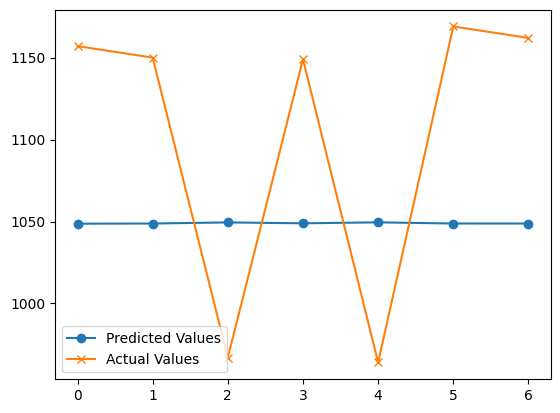

In [16]:
plt.plot(predictions_org, label="Predicted Values", marker="o")
plt.plot(y_test_org, label="Actual Values", marker="x")
plt.legend()
plt.show()